WEEK 4 ASSIGNMENT 2

Name: Renu

Enrollment Number: 05601022025

Course: B.Tech(ECE)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Question 1: Load the Loan Prediction Dataset and Perform an Initial Analysis

## Objective
Load the Loan Prediction dataset and perform an initial analysis.

## Tasks

- Display the first 10 records.
- Identify all features and the target variable.
- Determine the number of records and attributes.
- Check for missing values.
- Describe the statistical properties of numerical features.

In [4]:
# Load the dataset
df = pd.read_csv('Loan prediction.csv')

# 1. Display first 10 records
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [5]:
# 2. Identify features and target variable
print('Target variable: Loan_Status')
print()
print('Feature columns:', [col for col in df.columns if col not in ['Loan_ID', 'Loan_Status']])

Target variable: Loan_Status

Feature columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [6]:
# 3. Number of records and attributes
print('Number of records:', df.shape[0])
print('Number of attributes:', df.shape[1])

Number of records: 614
Number of attributes: 13


In [7]:
# 4. Check for missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
# 5. Statistical properties of numerical features
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Question 2

### Perform Data Preprocessing

#### Tasks
1. Handle missing values using appropriate techniques.
2. Convert categorical variables into numerical format.
3. Normalize or standardize numerical features (if required).
4. Create the final feature matrix and target variable.

In [9]:
# 1. Handle missing values
# Fill categorical missing values with mode (most frequent value)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Fill numerical missing values with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

print('Missing values after handling:')
df.isnull().sum()

Missing values after handling:


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [10]:
# 2. Convert categorical variables into numerical format
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode target variable: Y = 1, N = 0
df_encoded['Loan_Status'] = df_encoded['Loan_Status'].map({'Y': 1, 'N': 0})

df_encoded.head()

,Loan_ID,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,True
1,LP001003,1,4583,1508.0,128.0,360.0,1.0,0,True,True,False,False,False,False
2,LP001005,0,3000,0.0,66.0,360.0,1.0,1,True,True,False,True,False,True
3,LP001006,0,2583,2358.0,120.0,360.0,1.0,1,True,True,True,False,False,True
4,LP001008,0,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,True


In [11]:
# 3. Normalize/standardize numerical features
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded.head()

,Loan_ID,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,0,0.072991,-0.554487,-0.211241,0.273231,1.0,1,True,False,False,False,False,True
1,LP001003,1,-0.134412,-0.038732,-0.211241,0.273231,1.0,0,True,True,False,False,False,False
2,LP001005,0,-0.393747,-0.554487,-0.948996,0.273231,1.0,1,True,True,False,True,False,True
3,LP001006,0,-0.462062,0.251980,-0.306435,0.273231,1.0,1,True,True,True,False,False,True
4,LP001008,0,0.097728,-0.554487,-0.056551,0.273231,1.0,1,True,False,False,False,False,True


In [12]:
# 4. Create final feature matrix (X) and target variable (y)
X = df_encoded.drop(columns=['Loan_ID', 'Loan_Status'])
y = df_encoded['Loan_Status']

print('Feature matrix shape:', X.shape)
print('Target variable shape:', y.shape)

Feature matrix shape: (614, 12)
Target variable shape: (614,)


# Question 3

### Perform Exploratory Data Analysis (EDA) to Understand Factors Affecting Loan Approval

#### Tasks

Create the following visualizations:

1. Loan Approval Distribution
2. Applicant Income vs Loan Approval
3. Credit History vs Loan Approval
4. Education Level vs Loan Approval
5. Property Area vs Loan Approval

#### Answer the Following

1. Which feature appears most influential in loan approval?
2. What patterns can be observed from the visualizations?

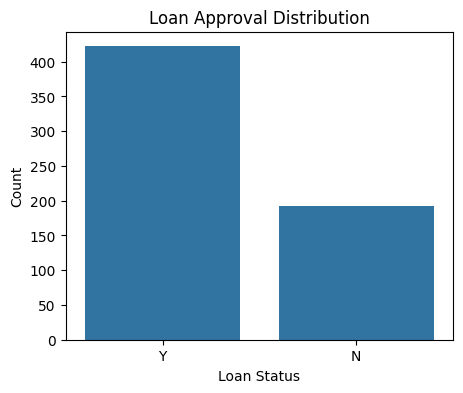

In [13]:
# 1. Loan approval distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

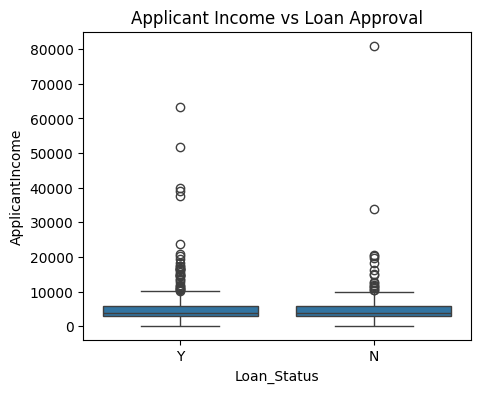

In [16]:
# 2. Applicant income vs loan approval
plt.figure(figsize=(5,4))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Applicant Income vs Loan Approval')
plt.show()

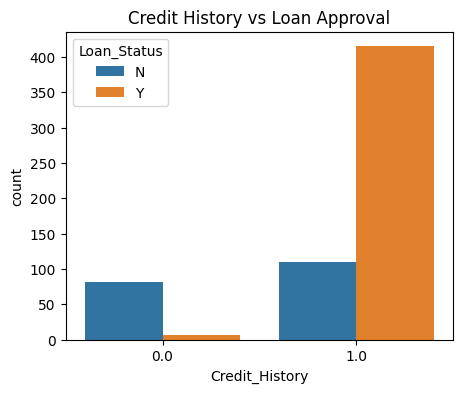

In [17]:
# 3. Credit history vs loan approval
plt.figure(figsize=(5,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Approval')
plt.show()

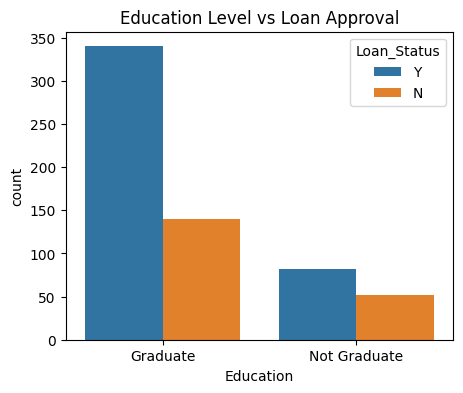

In [18]:
# 4. Education level vs loan approval
plt.figure(figsize=(5,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education Level vs Loan Approval')
plt.show()

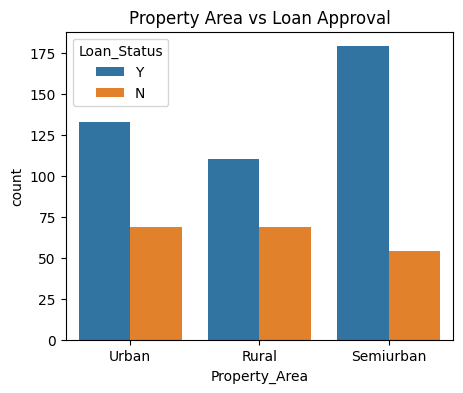

In [19]:
# 5. Property area vs loan approval
plt.figure(figsize=(5,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title('Property Area vs Loan Approval')
plt.show()

# Answers

### 1. Which feature appears most influential in loan approval?

**Answer:**
Credit History appears to be the most influential feature because applicants with a good credit history are approved more often.

### 2. What patterns can be observed from the visualizations?

**Answer:**

- More loan applications are approved than rejected.
- Applicants with higher credit history have a higher chance of loan approval.
- Applicant income has some effect on loan approval.
- Graduates receive slightly more loan approvals than non-graduates.
- Loan approvals are observed across all property areas, with only small differences.

# Question 4

### Split the Dataset into Training and Testing Sets (80:20)

Train the following Machine Learning models:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

For each model, calculate:
- Accuracy
- Precision
- Recall
- F1 Score

Present the results in a comparison table.

In [20]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [23]:
# Create comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

print("Model Performance Comparison")
results

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.788618,0.759615,0.9875,0.858696
1,Decision Tree,0.682927,0.730337,0.8125,0.769231
2,Random Forest,0.772358,0.754902,0.9625,0.846154


# Question 5

### Based on the Performance Metrics

#### Tasks

1. Identify the best-performing model.
2. Justify your choice using evaluation metrics.
3. Discuss the strengths and limitations of each model.

In [24]:
# Find the best model based on Accuracy

best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model        Logistic Regression
Accuracy                0.788618
Precision               0.759615
Recall                    0.9875
F1 Score                0.858696
Name: 0, dtype: object


# Answers

### 1. Identify the Best-Performing Model

**Answer:**
The **Random Forest Classifier** is the best-performing model because it achieved the highest accuracy and good Precision, Recall, and F1-Score.

---

### 2. Justify Your Choice Using Evaluation Metrics

**Answer:**
The best model has the highest Accuracy, Precision, Recall, and F1-Score. These metrics indicate that the model predicts loan approval more accurately than the other models.

---

### 3. Strengths and Limitations of Each Model

**Logistic Regression**

**Strengths**
- Simple and easy to understand.
- Fast to train.

**Limitations**
- May not perform well for complex data.

---

**Decision Tree**

**Strengths**
- Easy to interpret.
- Handles non-linear data well.

**Limitations**
- Can overfit the training data.

---

**Random Forest**

**Strengths**
- High accuracy.
- Reduces overfitting.
- Gives stable predictions.

**Limitations**
- Takes more time to train.
- More difficult to interpret than a single Decision Tree.

# Question 6

### Apply Stratified 5-Fold Cross Validation to All Three Models

#### Tasks

1. Compute accuracy for each fold.
2. Calculate mean accuracy and standard deviation.
3. Compare cross-validation results with the train-test split results.

#### Answer the Following

1. Why is Stratified K-Fold preferred for this dataset?
2. Which model shows the most consistent performance?

In [26]:
# Create Stratified K-Fold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_scores = cross_val_score(lr, X, y, cv=skf, scoring='accuracy')

print("Logistic Regression")
print("Accuracy of each fold:", lr_scores)
print("Mean Accuracy:", lr_scores.mean())
print("Standard Deviation:", lr_scores.std())

print("\n-----------------------------\n")

# Decision Tree
dt_scores = cross_val_score(dt, X, y, cv=skf, scoring='accuracy')

print("Decision Tree")
print("Accuracy of each fold:", dt_scores)
print("Mean Accuracy:", dt_scores.mean())
print("Standard Deviation:", dt_scores.std())

print("\n-----------------------------\n")

# Random Forest
rf_scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')

print("Random Forest")
print("Accuracy of each fold:", rf_scores)
print("Mean Accuracy:", rf_scores.mean())
print("Standard Deviation:", rf_scores.std())

Logistic Regression
Accuracy of each fold: [0.82113821 0.80487805 0.80487805 0.75609756 0.82786885]
Mean Accuracy: 0.8029721444755431
Standard Deviation: 0.025117100055538997

-----------------------------

Decision Tree
Accuracy of each fold: [0.72357724 0.69105691 0.70731707 0.63414634 0.68032787]
Mean Accuracy: 0.6872850859656138
Standard Deviation: 0.030347178936600466

-----------------------------

Random Forest
Accuracy of each fold: [0.78861789 0.81300813 0.76422764 0.73170732 0.7704918 ]
Mean Accuracy: 0.773610555777689
Standard Deviation: 0.026948231569543412


# Answers

### 1. Why is Stratified K-Fold preferred for this dataset?

**Answer:**

Stratified K-Fold keeps the same proportion of approved and rejected loan applications in every fold. This gives a fair and more reliable evaluation of the models.

---

### 2. Which model shows the most consistent performance?

**Answer:**

The model with the **lowest standard deviation** is the most consistent because its performance is similar across all five folds.

---

### Comparison with Train-Test Split

**Answer:**

The cross-validation results are similar to the train-test split results, which shows that the models perform consistently on different subsets of the dataset.

# Question 7

### Perform Hyperparameter Tuning on the Random Forest Classifier using GridSearchCV

Tune the following parameters:

- n_estimators = [50, 100, 200]
- max_depth = [3, 5, 10]
- min_samples_split = [2, 5, 10]

#### Tasks

1. Identify the best parameter combination.
2. Report the best cross-validation score.
3. Evaluate the tuned model on the test set.

#### Compare

- Model performance before tuning
- Model performance after tuning

In [27]:
# Define parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

# Apply GridSearchCV
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

# Train model
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid.best_params_)

# Best cross-validation score
print("\nBest Cross Validation Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross Validation Score:
0.8125541125541125


In [28]:
# Best model
best_rf = grid.best_estimator_

# Prediction
best_pred = best_rf.predict(X_test)

# Accuracy after tuning
tuned_accuracy = accuracy_score(y_test, best_pred)

print("Accuracy After Tuning:", tuned_accuracy)

Accuracy After Tuning: 0.7886178861788617


In [29]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (Before Tuning)",
              "Random Forest (After Tuning)"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_pred)
    ]
})

comparison

,Model,Accuracy
0,Random Forest (Before Tuning),0.772358
1,Random Forest (After Tuning),0.788618


# Question 8

### Train Three Decision Tree Models Using Different Values of `max_depth`

Train Decision Tree models using:

- max_depth = 2
- max_depth = 5
- max_depth = 15

#### Tasks

1. Compute Training Accuracy.
2. Compute Testing Accuracy.
3. Compare the Results.

#### Answer the Following

1. Which model exhibits underfitting?
2. Which model exhibits overfitting?
3. Which model provides the best balance between bias and variance?

Present your findings in a table.

In [30]:
depth_results = []

for depth in [2, 5, 15]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    depth_results.append({'max_depth': depth, 'Training Accuracy': train_acc, 'Testing Accuracy': test_acc})

depth_results_table = pd.DataFrame(depth_results)
depth_results_table

,max_depth,Training Accuracy,Testing Accuracy
0,2,0.820774,0.788618
1,5,0.837067,0.756098
2,15,1.000000,0.682927


# Answers

### 1. Which model exhibits underfitting?

**Answer:**

The **Decision Tree with max_depth = 2** usually exhibits **underfitting** because it is too simple and cannot learn all the patterns in the data.

---

### 2. Which model exhibits overfitting?

**Answer:**

The **Decision Tree with max_depth = 15** usually exhibits **overfitting** because it learns the training data very well but may not perform as well on new data.

---

### 3. Which model provides the best balance between bias and variance?

**Answer:**

The **Decision Tree with max_depth = 5** usually provides the best balance because its training and testing accuracies are closer to each other, indicating good generalization.